In [1]:
%load_ext autotime

import scarf

scarf.fetch_dataset("tenx_5K_pbmc_rnaseq", save_path="scarf_datasets", as_zarr=True)

ds = scarf.DataStore(
    "scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr", nthreads=4, min_features_per_cell=10
)

time: 31.1 s (started: 2026-06-29 18:26:21 +02:00)


INFO: 597 cells flagged for filtering out using attribute RNA_nCounts


INFO: Calculating summary statistics


INFO: Using cached feature stats for cell_key I


INFO: Using existing corrected dispersion values


INFO: Calculating HVGs


INFO: 500 genes marked as HVGs


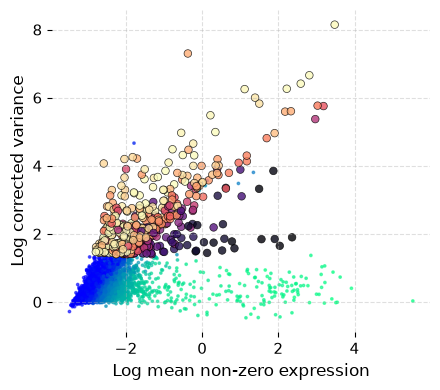

INFO: make_graph step 1/7: normalize expression matrix (computing)


Writing data to normed__I__hvgs/data:   0%|                                                                   …

INFO: make_graph step 1/7: normalize expression matrix finished in 0.4s (computing)


INFO: make_graph step 2/7: normalization statistics (computing)


Calculating mean and std. dev. of norm. data:   0%|                                                           …

...

INFO: make_graph step 7/7: finalize graph metadata (computing)


INFO: make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)


INFO: make_graph finished in 13.1s (7/7 steps, 13.0s in logged steps)


Training UMAP:   0%|                                                                                          …

time: 18.2 s (started: 2026-06-29 18:26:52 +02:00)


In [2]:
ds.filter_cells(attrs=["RNA_nCounts"], highs=[15000], lows=[1000])
ds.mark_hvgs(min_cells=20, top_n=500)
ds.make_graph(feat_key="hvgs", k=11, dims=15)
ds.run_umap(n_epochs=200, parallel=True)

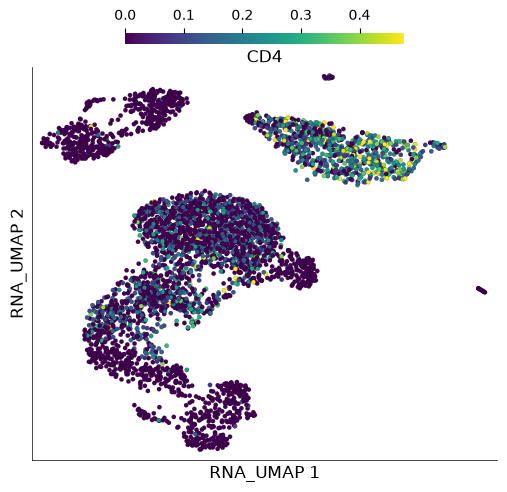

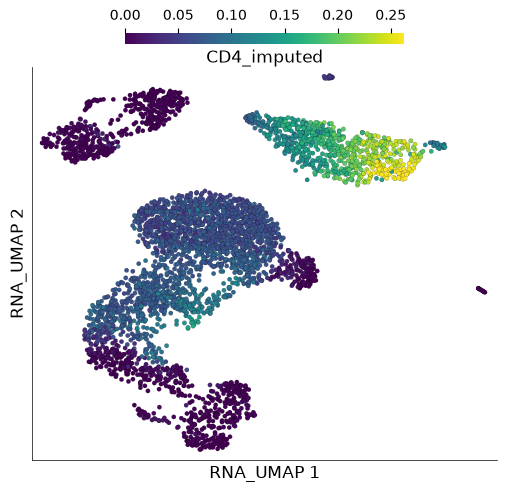

time: 1.72 s (started: 2026-06-29 18:27:10 +02:00)


In [3]:
imputed_cd4 = ds.get_imputed(feature_name="CD4", t=2)

ds.cells.insert("CD4_imputed", imputed_cd4, overwrite=True)

ds.plot_layout(layout_key="RNA_UMAP", color_by="CD4", from_assay="RNA")
ds.plot_layout(layout_key="RNA_UMAP", color_by="CD4_imputed")